Feature selection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\DATA SCIENCE\PROJECT FOLDERS\prj_power_consumption\std_features.csv")
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2.366171,2.479408,-1.851816,2.132316,-0.236518,0.556031,1.249421
1,2.828579,2.611191,-2.225274,2.435778,-0.236518,0.556031,1.130897
2,2.833706,3.052792,-2.330213,2.435778,-0.236518,1.167546,1.249421
3,2.838822,3.080651,-2.191324,2.435778,-0.236518,0.556031,1.249421
4,2.106331,3.259949,-1.592556,1.927098,-0.236518,0.556031,1.249421


In [14]:
df.shape

(2049280, 7)

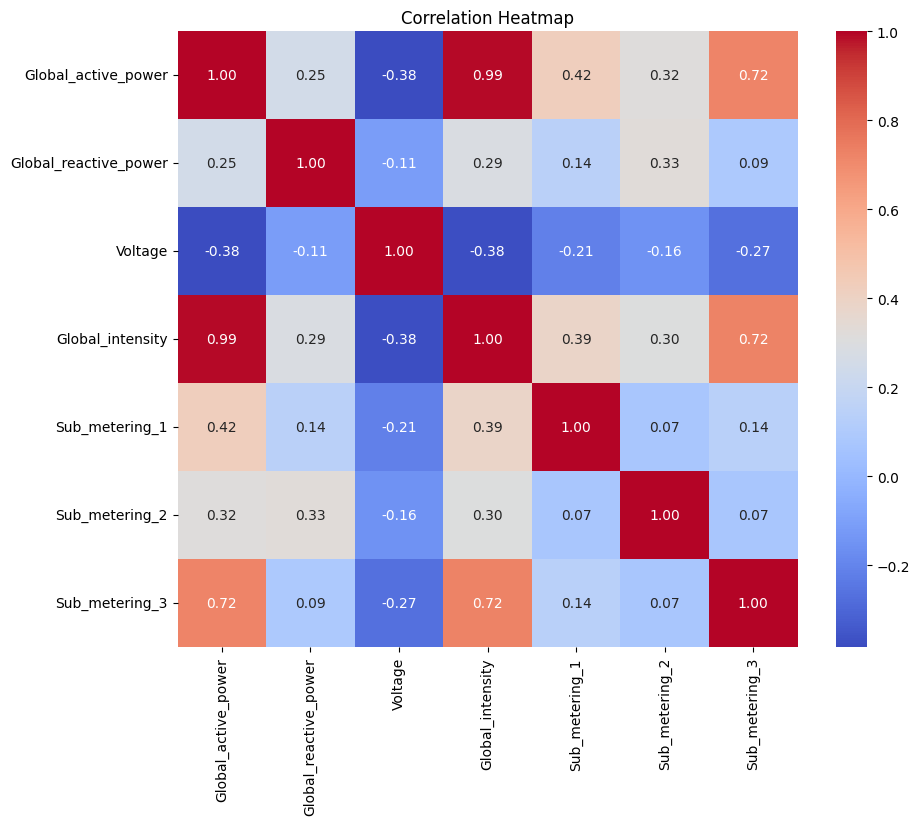

In [5]:
numeric_columns = df.select_dtypes(include=[np.number])
corr = numeric_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [6]:
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import RandomizedSearchCV

Linear regression model

In [4]:

X = df.drop(['Global_active_power', 'Global_intensity'], axis=1)
y = df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression Model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)
y_pred_linear = linear_reg_model.predict(X_test)

# Evaluation
print("Linear Regression Results:")
print(f"→ MSE: {mean_squared_error(y_test, y_pred_linear):.4f}")
print(f"→ R² Score: {r2_score(y_test, y_pred_linear):.4f}")
print("-" * 50)



Linear Regression Results:
→ MSE: 0.2954
→ R² Score: 0.7050
--------------------------------------------------


Cross validation corss val score 

In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(linear_reg_model, X_train, y_train, cv=10, scoring='r2')
print("Cross-Validation R² Scores:", scores)
print("Mean R²:", scores.mean())
print("Standard Deviation:", scores.std())


Cross-Validation R² Scores: [0.70366248 0.70274819 0.70107909 0.70270241 0.70185522 0.70359971
 0.70157115 0.70372005 0.70259119 0.70366767]
Mean R²: 0.7027197147063812
Standard Deviation: 0.0009131429347732482


Optimization

In [7]:
from sklearn.model_selection import cross_val_score

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score

# Split your data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Ridge model
ridge_model = Ridge()

# Set up the parameter grid for tuning
param_grid = {
    'alpha': [0.1, 1, 10, 100, 1000]  # Regularization strength
}

# Set up GridSearchCV
grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model
best_ridge_model = grid_search.best_estimator_

# Predict with the best model
y_pred_ridge = best_ridge_model.predict(X_test)

# Evaluate the model using R² score
r2_tuned = r2_score(y_test, y_pred_ridge)

print(f"Best Alpha (Regularization Strength): {grid_search.best_params_}")
print(f"R² Score on Test Set (After Ridge Optimization): {r2_tuned:.4f}")


Best Alpha (Regularization Strength): {'alpha': 10}
R² Score on Test Set (After Ridge Optimization): 0.7050


In [10]:
cv_scores = cross_val_score(best_ridge_model, X, y, cv=5, scoring='r2')  # 5-fold cross-validation

# Output the cross-validation results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Cross-Validation R²: {cv_scores.mean():.4f}")

Cross-Validation Scores: [0.64671874 0.68066582 0.67827517 0.74447488 0.75006173]
Mean Cross-Validation R²: 0.7000


 Random forest regressor 

In [ ]:
# Baseline Random Forest without tuning
baseline_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
baseline_rf.fit(X_train, y_train)
y_pred_rf = baseline_rf.predict(X_test)

print(f"R² Score (Simple RF): {r2_score(y_test, y_pred_rf):.4f}")

# Cross-validation
cv_scores_rf = cross_val_score(baseline_rf, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores (Simple RF): {cv_scores_rf}")
print(f"Mean Cross-Validation R² Score (Simple RF): {cv_scores_rf.mean():.4f}")

In [ ]:
# result
R² Score (Simple RF): 0.6186
Cross-Validation R² Scores (Simple RF): [0.51252936 0.49664308 0.36505886 0.37008793 0.10517246]
Mean Cross-Validation R² Score (Simple RF): 0.3699

In [ ]:
HPT - PIPELINE

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
import numpy as np

# Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
…r2_best_rf = r2_score(y_test, y_pred_best)

print(f"Best Hyperparameters from GridSearchCV: {grid_search.best_params_}")
print(f"R² Score (Tuned RF): {r2_best_rf:.4f}")

# Step 6: Cross-Validation R² for Tuned Model
cv_scores_tuned_rf = cross_val_score(best_rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"Cross-Validation R² Scores (Tuned RF): {cv_scores_tuned_rf}")
print(f"Mean Cross-Validation R² Score (Tuned RF): {cv_scores_tuned_rf.mean():.4f}")

In [ ]:
#RESULT
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters from GridSearchCV: {'rf__bootstrap': True, 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
R² Score (Tuned RF): 0.6727
Cross-Validation R² Scores (Tuned RF): [0.58095052 0.59931066 0.45606908 0.44439002 0.1883547 ]
Mean Cross-Validation R² Score (Tuned RF): 0.4538